In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  HÜCRE 1 — KURULUM                                      ║
# ╚══════════════════════════════════════════════════════════╝
!pip install -q gradio fpdf2 scikit-learn seaborn albumentations opencv-python-headless

import os, sys, json, random, shutil, zipfile, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.mixed_precision import set_global_policy

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, f1_score, cohen_kappa_score
)

warnings.filterwarnings('ignore')

# ── GPU + Mixed Precision ──────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    set_global_policy('mixed_float16')
    print(f'✅ GPU: {gpus[0].name}  |  Mixed Precision FP16 aktif')
else:
    print('⚠️  GPU bulunamadı — CPU kullanılıyor (yavaş olabilir)')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f'TF {tf.__version__}  |  Python {sys.version.split()[0]}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 24.8 MB/s eta 0:00:00
✅ GPU: /physical_device:GPU:0  |  Mixed Precision FP16 aktif
TF 2.19.0  |  Python 3.12.13


In [ ]:
!pip install kaggle -q

In [ ]:
from google.colab import files

print('Lütfen kaggle.json dosyanızı seçin:')
uploaded = files.upload()

for fn in uploaded.keys():
    print('Yüklenen dosya: "{name}" ({length} bytes)'.format(name=fn, length=len(uploaded[fn])))

# Dosyayı doğru yere taşı (eğer adı kaggle.json ise)
if 'kaggle.json' in uploaded:
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print('kaggle.json dosyası ~/.kaggle dizinine taşındı ve izinleri ayarlandı.')
else:
    print('kaggle.json dosyası bulunamadı. Lütfen doğru dosyayı yüklediğinizden emin olun.')

Lütfen kaggle.json dosyanızı seçin:


Saving kaggle.json to kaggle.json
Yüklenen dosya: "kaggle.json" (74 bytes)
kaggle.json dosyası ~/.kaggle dizinine taşındı ve izinleri ayarlandı.


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  HÜCRE 2 — VERİ İNDİRME                                 ║
# ║  Kaggle: plameneduardo/sarscov2-ctscan-dataset           ║
# ║  (COVID / NonCOVID — 2482 CT görüntüsü, CC BY 4.0)      ║
# ╚══════════════════════════════════════════════════════════╝
DATA_DIR = Path('/content/ct_data')
DATA_DIR.mkdir(exist_ok=True)

CLASSES = None  # sonradan belirlenir

# ── Kaggle API ─────────────────────────────────────────────
def try_kaggle():
    # Check if kaggle.json exists in the correct location (~/.kaggle)
    kaggle_json_path = Path('/root/.kaggle/kaggle.json')
    if not kaggle_json_path.exists():
        return False

    # If it exists, proceed with downloading the dataset
    print('✅ kaggle.json bulundu, veri seti indiriliyor...')
    ret = os.system(
        'kaggle datasets download -d plameneduardo/sarscov2-ctscan-dataset ' +
        '-p /content/ct_raw --unzip -q'
    )
    return ret == 0

# ── Kaggle verisini bölme ───────────────────────────────────
def split_kaggle():
    raw = Path('/content/ct_raw')
    cls_dirs = [d for d in raw.iterdir() if d.is_dir()]
    for cls_dir in cls_dirs:
        files = sorted(cls_dir.glob('*.*'))
        random.shuffle(files)
        n = len(files)
        cuts = {'train': files[:int(n*.70)],
                'val':   files[int(n*.70):int(n*.85)],
                'test':  files[int(n*.85):]}
        for split, flist in cuts.items():
            dest = DATA_DIR / split / cls_dir.name
            dest.mkdir(parents=True, exist_ok=True)
            for f in flist:
                shutil.copy(f, dest / f.name)
    print('✅ Kaggle verisi bölündü (70/15/15)')

# ── Sentetik demo verisi (Kaggle yoksa) ────────────────────
def make_demo(n_per_cls=300):
    print('🔧 Sentetik CT verisi üretiliyor...')
    SZ = 224
    Y, X = np.ogrid[:SZ, :SZ]
    cx, cy = SZ//2, SZ//2

    def lung_mask():
        ml = ((X-cx+38)**2/38**2 + (Y-cy)**2/58**2) < 1
        mr = ((X-cx-38)**2/38**2 + (Y-cy)**2/58**2) < 1
        return ml | mr

    def make_img(label):
        img = np.random.normal(0.06, 0.025, (SZ, SZ)).clip(0, .4).astype(np.float32)
        lm = lung_mask()
        img[lm] = np.random.uniform(.15, .35, lm.sum())
        if label == 'COVID':
            for _ in range(random.randint(2, 5)):
                lx = random.choice([cx-38, cx+38]) + random.randint(-14, 14)
                ly = cy + random.randint(-32, 32)
                rx, ry = random.randint(18, 55), random.randint(14, 45)
                op = ((X-lx)**2/rx**2 + (Y-ly)**2/ry**2) < 1
                op &= lm
                img[op] = np.random.uniform(.52, .78)
        img += np.random.normal(0, .025, (SZ, SZ))
        img = img.clip(0, 1)
        mn, mx = img.min(), img.max()
        img = ((img - mn) / (mx - mn + 1e-8) * 255).astype(np.uint8)
        return np.stack([img]*3, -1)

    ratios = {'train': .70, 'val': .15, 'test': .15}
    for cls in ['COVID', 'NonCOVID']:
        idx = 0
        for split, r in ratios.items():
            p = DATA_DIR / split / cls; p.mkdir(parents=True, exist_ok=True)
            for _ in range(int(n_per_cls * r)):
                Image.fromarray(make_img(cls)).save(p / f'{cls}_{idx:05d}.png')
                idx += 1
    print('✅ Sentetik veri hazır')

# ── Çalıştır ───────────────────────────────────────────────
print('📥 Kaggle.json aranıyor...')
if try_kaggle():
    split_kaggle()
else:
    print('ℹ️  kaggle.json bulunamadı veya indirme başarısız → sentetik demo modu')
    make_demo(n_per_cls=320)

CLASSES = sorted(os.listdir(DATA_DIR / 'train'))
N_CLS   = len(CLASSES)
print(f'\n📂 Sınıflar: {CLASSES}  (N={N_CLS})')
for sp in ['train', 'val', 'test']:
    counts = {c: len(list((DATA_DIR/sp/c).glob('*.*'))) for c in CLASSES}
    print(f'  {sp:5s}: {counts}  → toplam {sum(counts.values())}')

📥 Kaggle.json aranıyor...
✅ kaggle.json bulundu, veri seti indiriliyor...
✅ Kaggle verisi bölündü (70/15/15)

📂 Sınıflar: ['COVID', 'non-COVID']  (N=2)
  train: {'COVID': 876, 'non-COVID': 860}  → toplam 1736
  val  : {'COVID': 188, 'non-COVID': 184}  → toplam 372
  test : {'COVID': 188, 'non-COVID': 185}  → toplam 373


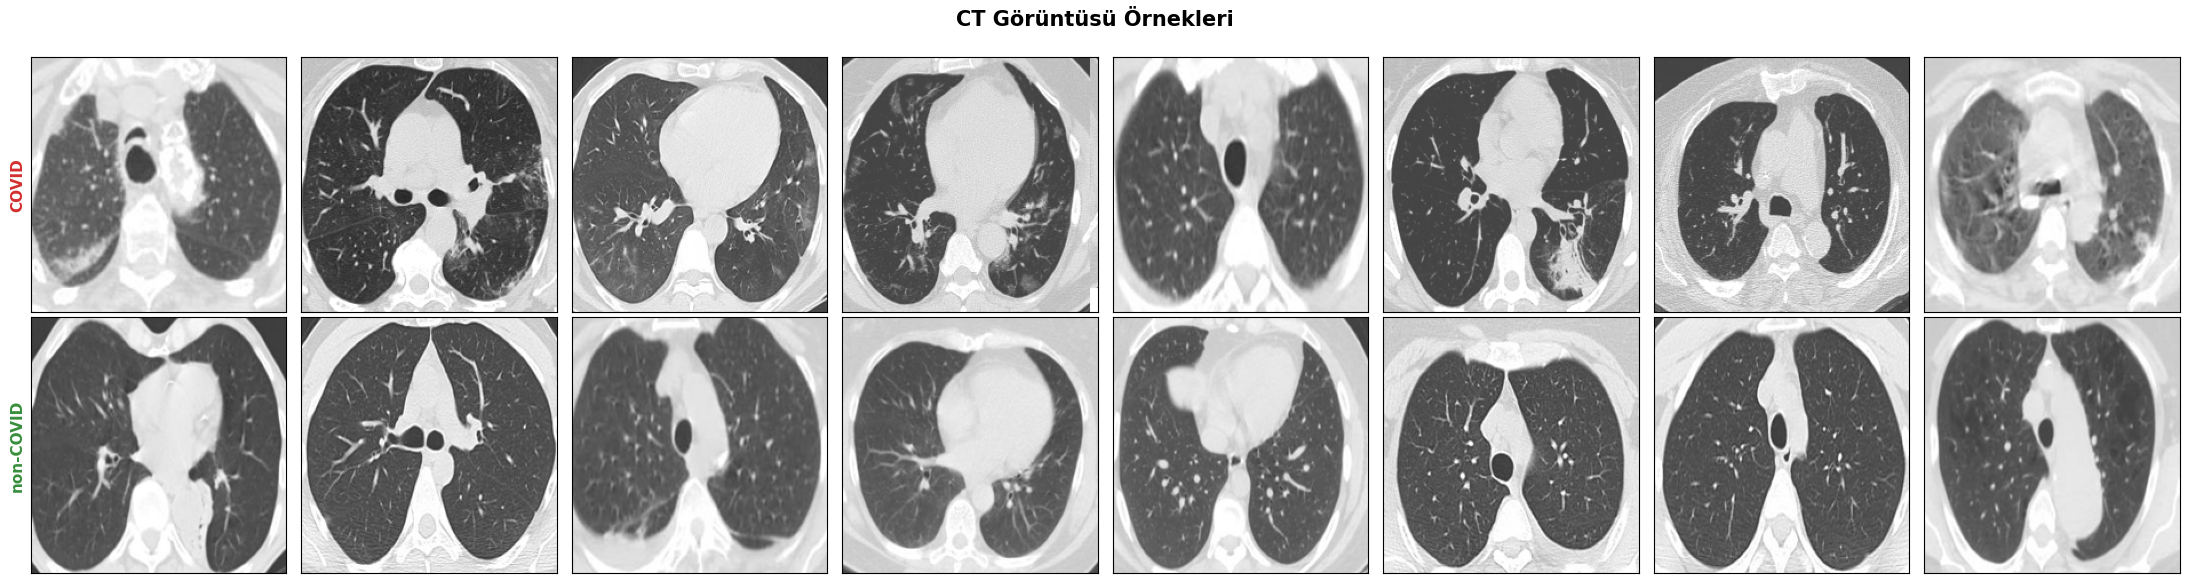

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  HÜCRE 3 — VERİ GÖRSELLEŞTİRME                        ║
# ╚══════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(N_CLS, 8, figsize=(22, N_CLS*3))
fig.suptitle('CT Görüntüsü Örnekleri', fontsize=15, fontweight='bold')
for i, cls in enumerate(CLASSES):
    files = list((DATA_DIR/'train'/cls).glob('*.*'))[:8]
    for j, f in enumerate(files):
        ax = axes[i,j] if N_CLS > 1 else axes[j]
        ax.imshow(Image.open(f).convert('RGB').resize((224,224)), cmap='gray')
        if j == 0:
            color = '#d32f2f' if cls=='COVID' else '#388e3c'
            ax.set_ylabel(cls, fontsize=11, color=color, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  HÜCRE 4 — tf.data PIPELINE                             ║
# ╚══════════════════════════════════════════════════════════╝
IMG_SIZE   = 384    # EfficientNetV2-S için en iyi boyut
BATCH_SIZE = 16     # T4 16 GB → 16 rahat gider; A100 ise 32
AUTOTUNE   = tf.data.AUTOTUNE

# Sınıf ağırlıkları (dengesizlik)
train_counts = {c: len(list((DATA_DIR/'train'/c).glob('*.*'))) for c in CLASSES}
total_tr = sum(train_counts.values())
CLS_WEIGHTS = {i: total_tr/(N_CLS*v) for i,(k,v) in enumerate(sorted(train_counts.items()))}
print('Sınıf ağırlıkları:', CLS_WEIGHTS)

def load_img(path, label, aug=False):
    raw  = tf.io.read_file(path)
    img  = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img  = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img  = tf.cast(img, tf.float32)
    if aug:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, .12)
        img = tf.image.random_contrast(img, .88, 1.12)
        img = tf.image.random_saturation(img, .88, 1.12)
        img = tf.image.random_hue(img, .04)
        img = tf.clip_by_value(img, 0., 255.)
    img = tf.keras.applications.efficientnet_v2.preprocess_input(img)
    return img, label

def make_ds(split, aug=False):
    paths, labels = [], []
    for i, cls in enumerate(sorted(CLASSES)):
        fs = list((DATA_DIR/split/cls).glob('*.*'))
        paths  += [str(f) for f in fs]
        labels += [i] * len(fs)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if aug: ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(lambda p,l: load_img(p,l,aug), num_parallel_calls=AUTOTUNE)
    if N_CLS > 2: ds = ds.map(lambda x,y: (x, tf.one_hot(y, N_CLS)))
    if aug: ds = ds.repeat()
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE), len(paths)

train_ds, N_TRAIN = make_ds('train', aug=True)
val_ds,   N_VAL   = make_ds('val')
test_ds,  N_TEST  = make_ds('test')

STEPS = N_TRAIN // BATCH_SIZE
print(f'Train:{N_TRAIN}  Val:{N_VAL}  Test:{N_TEST}  Steps/epoch:{STEPS}')

Sınıf ağırlıkları: {0: 0.9908675799086758, 1: 1.0093023255813953}
Train:1736  Val:372  Test:373  Steps/epoch:108


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  HÜCRE 5 — MODEL: EfficientNetV2-S + Dual Pooling       ║
# ╚══════════════════════════════════════════════════════════╝
def build_model(img_size=IMG_SIZE, n_cls=N_CLS, drop=0.40):
    inp  = layers.Input((img_size, img_size, 3))
    base = EfficientNetV2S(include_top=False, weights='imagenet', input_tensor=inp)
    base.trainable = False  # Phase-1'de dondur

    x    = base.output
    gavg = layers.GlobalAveragePooling2D()(x)
    gmax = layers.GlobalMaxPooling2D()(x)
    x    = layers.Concatenate()([gavg, gmax])

    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(drop)(x)

    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(drop * 0.75)(x)

    act   = 'softmax' if n_cls > 2 else 'sigmoid'
    out   = layers.Dense(n_cls if n_cls > 2 else 1,
                         activation=act, dtype='float32')(x)
    return Model(inp, out, name='CT_EffNetV2S'), base

model, backbone = build_model()

total_p     = model.count_params()
trainable_p = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Toplam: {total_p:,}  |  Eğitilebilir: {trainable_p:,}  |  Dondurulmuş: {total_p-trainable_p:,}')

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Toplam: 21,777,249  |  Eğitilebilir: 1,444,353  |  Dondurulmuş: 20,332,896


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  HÜCRE 6 — PHASE 1: WARM-UP (backbone dondurulmuş)      ║
# ╚══════════════════════════════════════════════════════════╝
LOSS = (tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.10)
        if N_CLS > 2 else tf.keras.losses.BinaryCrossentropy())

def compile_model(lr):
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=LOSS,
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )

compile_model(1e-3)

cb1 = [
    ModelCheckpoint('/content/ckpt_phase1.keras',
                    monitor='val_auc', mode='max', save_best_only=True, verbose=0),
    EarlyStopping(monitor='val_auc', patience=7, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.LearningRateScheduler(
        lambda e: 1e-3 * (e+1)/5 if e < 5 else 1e-3, verbose=0)
]

print('─'*55)
print('  PHASE 1 — Warm-up  (backbone dondurulmuş)')
print('─'*55)
h1 = model.fit(
    train_ds, epochs=15, steps_per_epoch=STEPS,
    validation_data=val_ds, validation_steps=N_VAL//BATCH_SIZE+1,
    callbacks=cb1,
    class_weight=CLS_WEIGHTS if N_CLS == 2 else None,
    verbose=1
)
print(f'Phase-1 en iyi val_auc: {max(h1.history["val_auc"]):.4f}')

───────────────────────────────────────────────────────
  PHASE 1 — Warm-up  (backbone dondurulmuş)
───────────────────────────────────────────────────────
Epoch 1/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 160s 660ms/step - accuracy: 0.7338 - auc: 0.8069 - loss: 0.5410 - precision: 0.7115 - recall: 0.7780 - val_accuracy: 0.8091 - val_auc: 0.9207 - val_loss: 0.4498 - val_precision: 0.9248 - val_recall: 0.6685 - learning_rate: 2.0000e-04
Epoch 2/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step - accuracy: 0.8166 - auc: 0.8957 - loss: 0.4085 - precision: 0.7980 - recall: 0.8419 - val_accuracy: 0.8360 - val_auc: 0.9348 - val_loss: 0.4140 - val_precision: 0.9241 - val_recall: 0.7283 - learning_rate: 4.0000e-04
Epoch 3/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.8542 - auc: 0.9317 - loss: 0.3328 - precision: 0.8489 - recall: 0.8588 - val_accuracy: 0.8602 - val_auc: 0.9423 - val_loss: 0.3965 - val_precision: 0.8000 - val_recall: 0.9565 - learning_rate: 6.0000e-04
Epoch 4/15
108/108 ━━━━━

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  HÜCRE 7 — PHASE 2: FINE-TUNING (son %40 serbest)       ║
# ╚══════════════════════════════════════════════════════════╝
backbone.trainable = True
n_layers           = len(backbone.layers)
freeze_until       = int(n_layers * 0.60)   # son %40 serbest
for l in backbone.layers[:freeze_until]:  l.trainable = False
for l in backbone.layers[freeze_until:]:  l.trainable = True

compile_model(5e-5)    # fine-tune için çok düşük LR

cb2 = [
    ModelCheckpoint('/content/best_model.keras',
                    monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=4, min_lr=1e-7, verbose=1)
]

print('─'*55)
print(f'  PHASE 2 — Fine-tuning  (katman {freeze_until}+ serbest)')
print('─'*55)
h2 = model.fit(
    train_ds, epochs=35, steps_per_epoch=STEPS,
    validation_data=val_ds, validation_steps=N_VAL//BATCH_SIZE+1,
    callbacks=cb2,
    class_weight=CLS_WEIGHTS if N_CLS == 2 else None,
    verbose=1
)
print(f'Phase-2 en iyi val_auc: {max(h2.history["val_auc"]):.4f}')

───────────────────────────────────────────────────────
  PHASE 2 — Fine-tuning  (katman 307+ serbest)
───────────────────────────────────────────────────────
Epoch 1/35
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8041 - auc: 0.8883 - loss: 0.4952 - precision: 0.7996 - recall: 0.8110
Epoch 1: val_auc improved from None to 0.97035, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 243s 999ms/step - accuracy: 0.8403 - auc: 0.9218 - loss: 0.4061 - precision: 0.8314 - recall: 0.8508 - val_accuracy: 0.9220 - val_auc: 0.9704 - val_loss: 0.2368 - val_precision: 0.9144 - val_recall: 0.9293 - learning_rate: 5.0000e-05
Epoch 2/35
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8909 - auc: 0.9609 - loss: 0.2599 - precision: 0.8796 - recall: 0.9125
Epoch 2: val_auc improved from 0.97035 to 0.98867, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.k

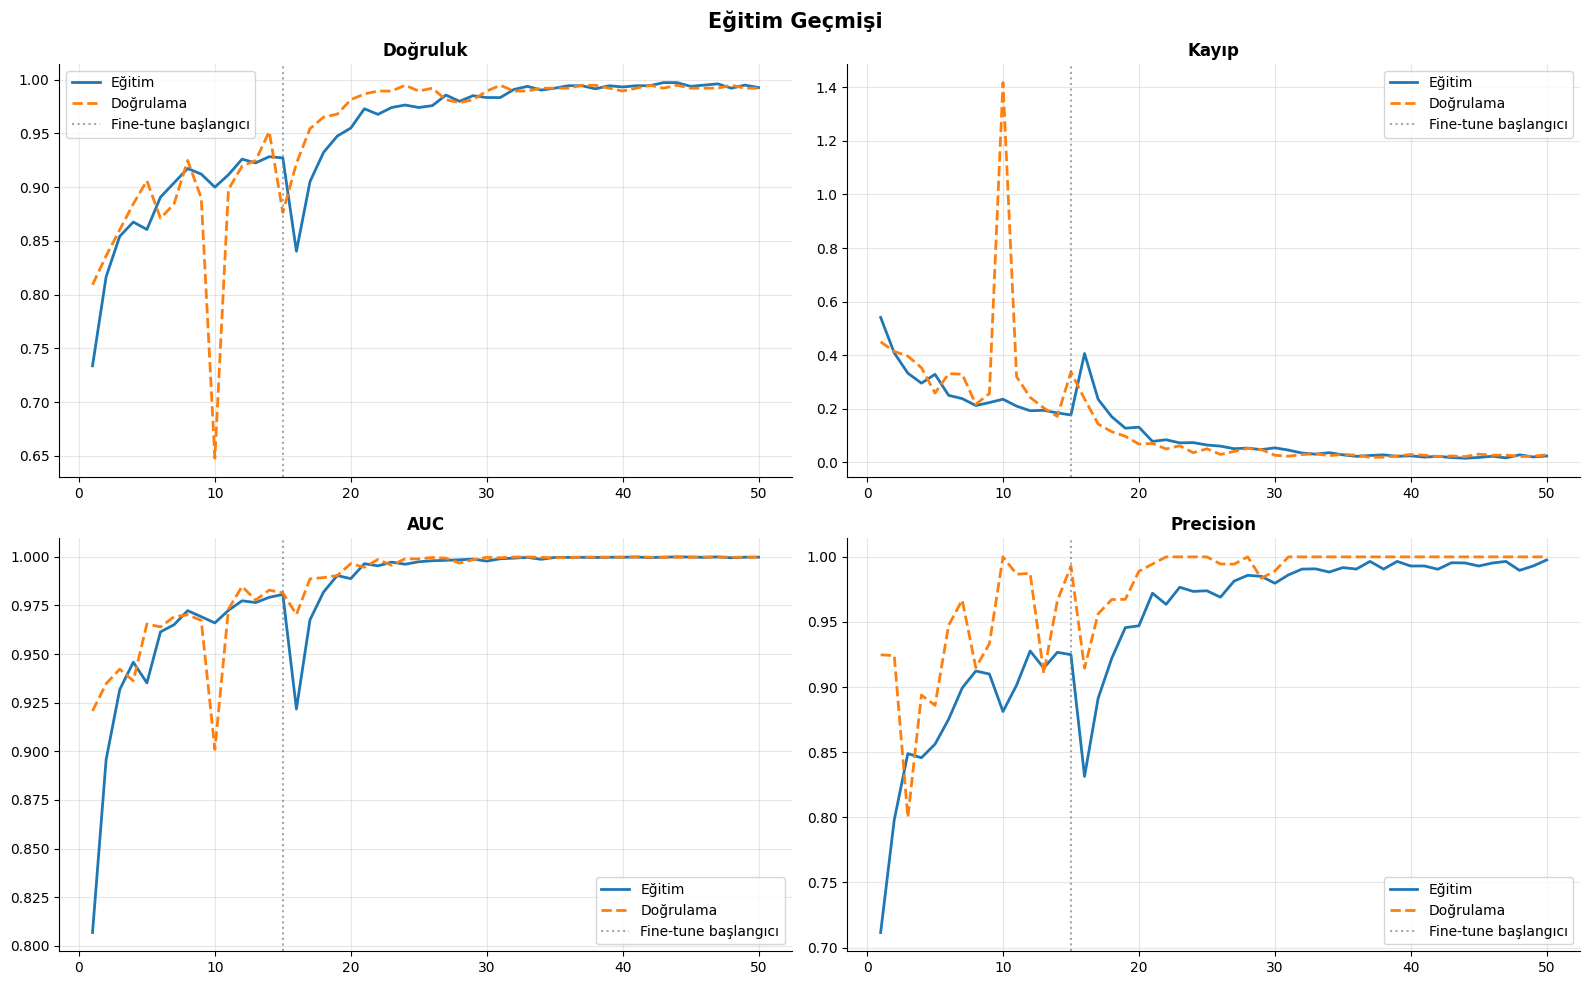

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  HÜCRE 8 — EĞİTİM GEÇMİŞİ GRAFİKLERİ                  ║
# ╚══════════════════════════════════════════════════════════╝
hist = {k: h1.history[k] + h2.history[k] for k in h1.history}
E1   = len(h1.history['loss'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Eğitim Geçmişi', fontsize=15, fontweight='bold')

pairs = [('accuracy','val_accuracy','Doğruluk'),
         ('loss','val_loss','Kayıp'),
         ('auc','val_auc','AUC'),
         ('precision','val_precision','Precision')]

for ax, (tk, vk, title) in zip(axes.flatten(), pairs):
    ep = range(1, len(hist[tk])+1)
    ax.plot(ep, hist[tk], lw=2, label='Eğitim')
    ax.plot(ep, hist[vk], lw=2, ls='--', label='Doğrulama')
    ax.axvline(E1, color='gray', ls=':', alpha=.7, label='Fine-tune başlangıcı')
    ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(alpha=.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  HÜCRE 9 — TEST DEĞERLENDİRME + TTA (5x)               ║
# ╚══════════════════════════════════════════════════════════╝
model = tf.keras.models.load_model('/content/best_model.keras')

TTA_TRANSFORMS = [
    lambda x: x,
    lambda x: tf.image.flip_left_right(x),
    lambda x: tf.image.flip_up_down(x),
    lambda x: tf.image.adjust_brightness(x, delta=.06),
    lambda x: tf.image.adjust_contrast(x, contrast_factor=1.10),
]

OUT_DIM  = N_CLS if N_CLS > 2 else 1
y_true_all, y_prob_all = [], None

for i, t in enumerate(TTA_TRANSFORMS):
    probs_i, labels_i = [], []
    for imgs, lbls in test_ds:
        if i == 0: labels_i.extend(lbls.numpy().tolist())
        p = model(t(imgs), training=False).numpy()
        probs_i.extend(p)
    probs_i = np.array(probs_i)
    if i == 0:
        y_true_all = np.array(labels_i)
        if N_CLS > 2: y_true_all = np.argmax(y_true_all, axis=1)
        y_prob_all  = probs_i
    else:
        y_prob_all += probs_i

y_prob_all /= len(TTA_TRANSFORMS)

if N_CLS == 2:
    y_prob_flat = y_prob_all.flatten()
    y_pred      = (y_prob_flat > .5).astype(int)
    AUC         = roc_auc_score(y_true_all, y_prob_flat)
else:
    y_pred = np.argmax(y_prob_all, axis=1)
    AUC    = roc_auc_score(y_true_all, y_prob_all, multi_class='ovr')

ACC   = accuracy_score(y_true_all, y_pred)
F1M   = f1_score(y_true_all, y_pred, average='macro')
F1W   = f1_score(y_true_all, y_pred, average='weighted')
KAPPA = cohen_kappa_score(y_true_all, y_pred)

print('═'*55)
print('  TEST SONUÇLARI  (TTA × 5)')
print('═'*55)
print(f'  Accuracy         : {ACC:.4f}  ({ACC*100:.2f}%)')
print(f'  AUC-ROC          : {AUC:.4f}')
print(f'  F1-Score (Macro) : {F1M:.4f}')
print(f'  F1-Score (Wght)  : {F1W:.4f}')
print(f'  Cohen Kappa      : {KAPPA:.4f}')
print('═'*55)
print(classification_report(y_true_all, y_pred, target_names=sorted(CLASSES)))

RESULTS = dict(accuracy=float(ACC), auc=float(AUC), f1_macro=float(F1M),
               f1_weighted=float(F1W), kappa=float(KAPPA),
               classes=sorted(CLASSES), n_test=int(N_TEST),
               model='EfficientNetV2-S', img_size=IMG_SIZE,
               timestamp=datetime.now().isoformat())
json.dump(RESULTS, open('/content/results.json','w'), indent=2)

═══════════════════════════════════════════════════════
  TEST SONUÇLARI  (TTA × 5)
═══════════════════════════════════════════════════════
  Accuracy         : 0.9946  (99.46%)
  AUC-ROC          : 0.9994
  F1-Score (Macro) : 0.9946
  F1-Score (Wght)  : 0.9946
  Cohen Kappa      : 0.9893
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

       COVID       0.99      1.00      0.99       188
   non-COVID       1.00      0.99      0.99       185

    accuracy                           0.99       373
   macro avg       0.99      0.99      0.99       373
weighted avg       0.99      0.99      0.99       373



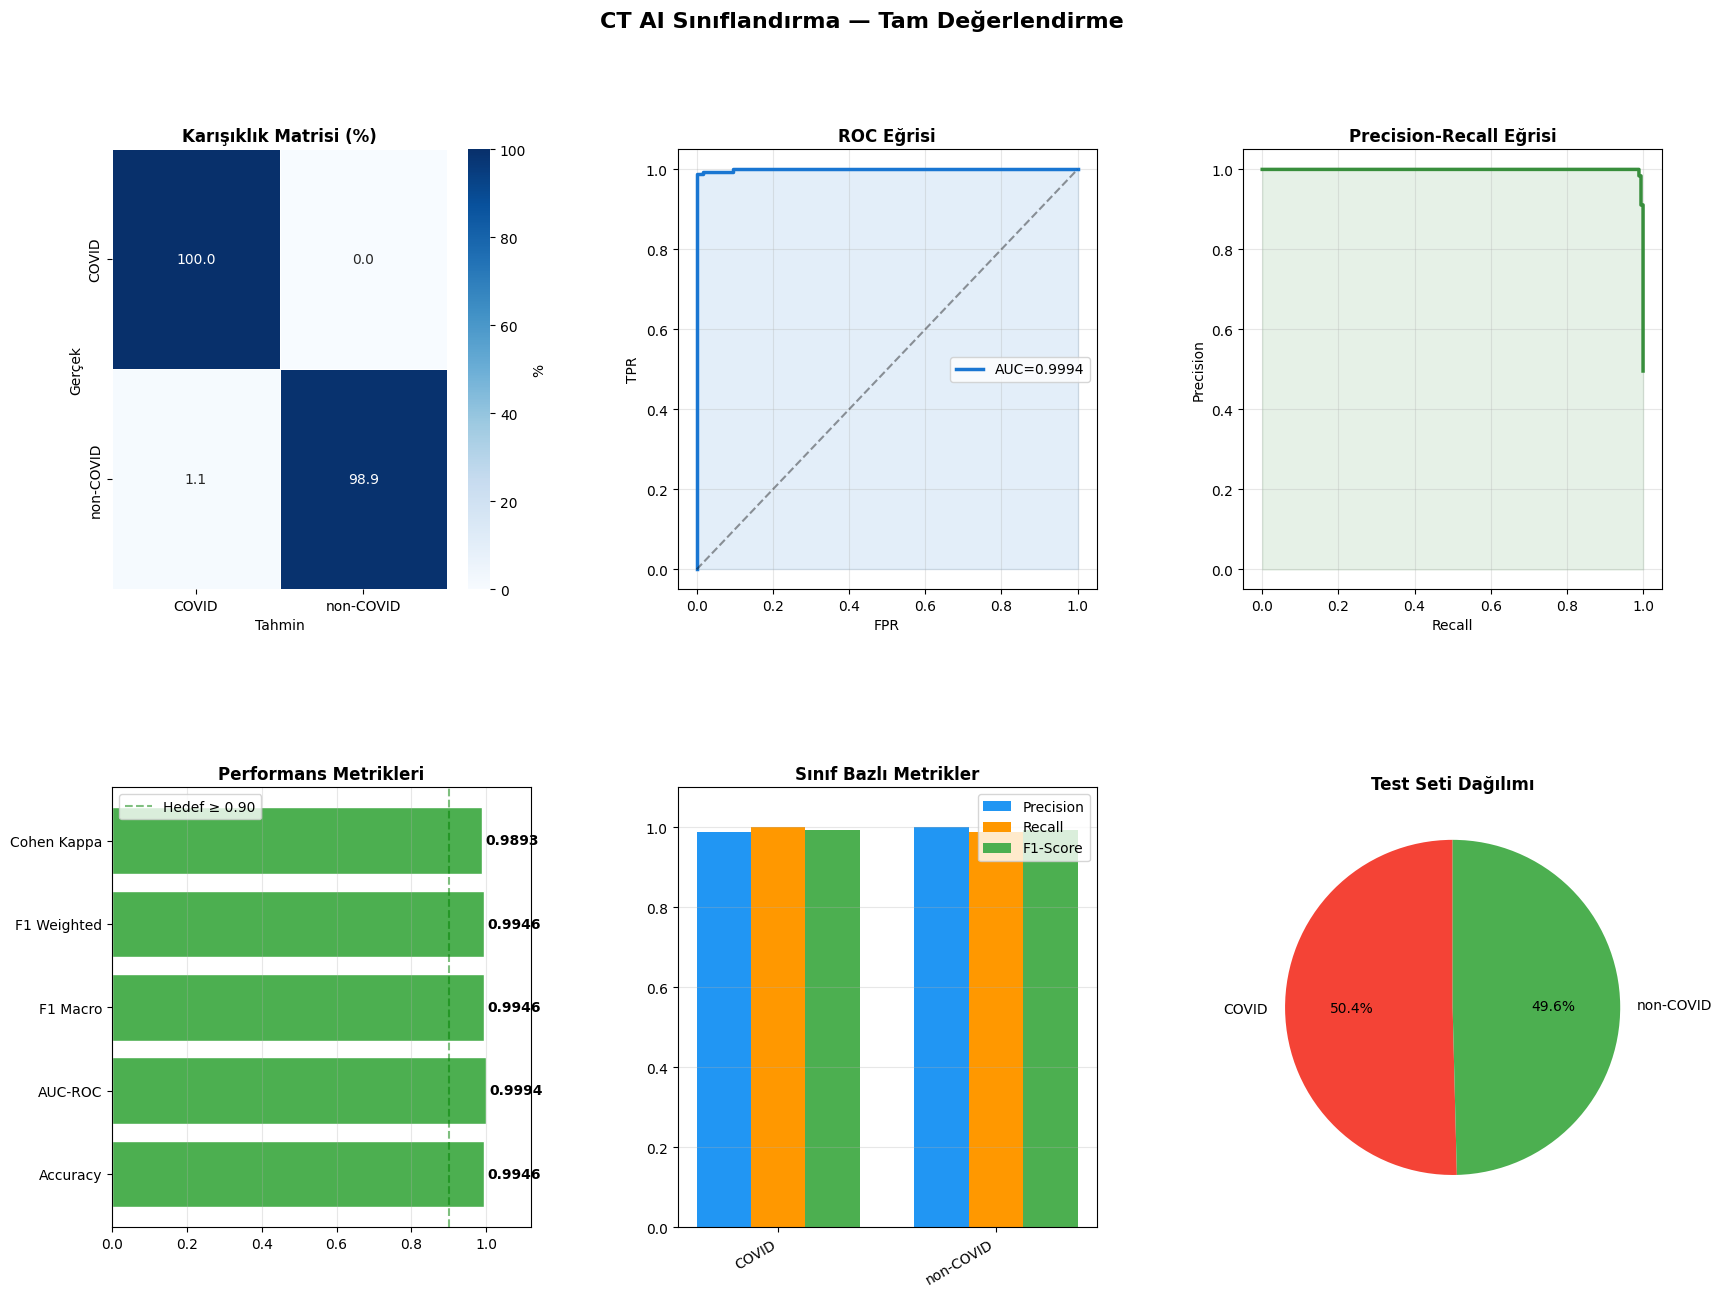

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  HÜCRE 10 — DETAYLI METRİK GRAFİKLERİ                  ║
# ╚══════════════════════════════════════════════════════════╝
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, hspace=.45, wspace=.35)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0,0])
cm  = confusion_matrix(y_true_all, y_pred)
cmp = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cmp, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=sorted(CLASSES), yticklabels=sorted(CLASSES),
            ax=ax1, linewidths=.5, cbar_kws={'label':'%'})
ax1.set_title('Karışıklık Matrisi (%)', fontweight='bold')
ax1.set_ylabel('Gerçek'); ax1.set_xlabel('Tahmin')

# 2. ROC
ax2 = fig.add_subplot(gs[0,1])
if N_CLS == 2:
    fpr, tpr, _ = roc_curve(y_true_all, y_prob_flat)
    ax2.fill_between(fpr, tpr, alpha=.12, color='#1976D2')
    ax2.plot(fpr, tpr, lw=2.5, color='#1976D2', label=f'AUC={AUC:.4f}')
else:
    from sklearn.preprocessing import label_binarize
    yb = label_binarize(y_true_all, classes=range(N_CLS))
    for i, c in enumerate(sorted(CLASSES)):
        fpr_i, tpr_i, _ = roc_curve(yb[:,i], y_prob_all[:,i])
        ax2.plot(fpr_i, tpr_i, lw=2, label=f'{c}')
ax2.plot([0,1],[0,1],'k--',alpha=.4)
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.set_title('ROC Eğrisi', fontweight='bold')
ax2.legend(); ax2.grid(alpha=.3)

# 3. Precision-Recall
ax3 = fig.add_subplot(gs[0,2])
if N_CLS == 2:
    pr, rc, _ = precision_recall_curve(y_true_all, y_prob_flat)
    ax3.fill_between(rc, pr, alpha=.12, color='#388E3C')
    ax3.plot(rc, pr, lw=2.5, color='#388E3C')
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Eğrisi', fontweight='bold')
ax3.grid(alpha=.3)

# 4. Genel metrikler
ax4 = fig.add_subplot(gs[1,0])
mnames = ['Accuracy','AUC-ROC','F1 Macro','F1 Weighted','Cohen Kappa']
mvals  = [ACC, AUC, F1M, F1W, KAPPA]
mcolors= ['#4CAF50' if v>=.9 else '#FF9800' if v>=.7 else '#F44336' for v in mvals]
bars = ax4.barh(mnames, mvals, color=mcolors, edgecolor='white')
for b, v in zip(bars, mvals):
    ax4.text(b.get_width()+.01, b.get_y()+b.get_height()/2,
             f'{v:.4f}', va='center', fontweight='bold', fontsize=10)
ax4.set_xlim(0, 1.12)
ax4.axvline(.9, color='green', ls='--', alpha=.5, label='Hedef ≥ 0.90')
ax4.set_title('Performans Metrikleri', fontweight='bold')
ax4.legend(); ax4.grid(alpha=.3, axis='x')

# 5. Sınıf bazlı F1/P/R
ax5  = fig.add_subplot(gs[1,1])
rpt  = classification_report(y_true_all, y_pred, target_names=sorted(CLASSES), output_dict=True)
cnames = sorted(CLASSES)
x = np.arange(len(cnames)); w = .25
ax5.bar(x-w, [rpt[c]['precision'] for c in cnames], w, label='Precision', color='#2196F3')
ax5.bar(x,   [rpt[c]['recall']    for c in cnames], w, label='Recall',    color='#FF9800')
ax5.bar(x+w, [rpt[c]['f1-score']  for c in cnames], w, label='F1-Score',  color='#4CAF50')
ax5.set_xticks(x); ax5.set_xticklabels(cnames, rotation=30, ha='right')
ax5.set_ylim(0,1.1); ax5.set_title('Sınıf Bazlı Metrikler', fontweight='bold')
ax5.legend(); ax5.grid(alpha=.3, axis='y')

# 6. Sınıf dağılımı
ax6 = fig.add_subplot(gs[1,2])
u, cnt = np.unique(y_true_all, return_counts=True)
ax6.pie(cnt, labels=[sorted(CLASSES)[i] for i in u], autopct='%1.1f%%',
        startangle=90, colors=['#F44336','#4CAF50'][:len(u)])
ax6.set_title('Test Seti Dağılımı', fontweight='bold')

fig.suptitle('CT AI Sınıflandırma — Tam Değerlendirme', fontsize=16, fontweight='bold')
plt.savefig('/content/evaluation_results.png', dpi=130, bbox_inches='tight')
plt.show()

In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║  HÜCRE 13 — GRADIO WEB ARAYÜZÜ                          ║
# ║  share=True → dışarıdan erişilebilir genel link         ║
# ╚══════════════════════════════════════════════════════════╝
import gradio as gr

# ── Tahmin fonksiyonu ──────────────────────────────────────
def ct_tahmin(goruntu):
    if goruntu is None:
        return None, "⚠️ Lütfen bir CT görüntüsü yükleyin."

    img = Image.fromarray(goruntu).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = tf.keras.applications.efficientnet_v2.preprocess_input(
              np.array(img, np.float32)[None])

    # TTA × 3 (Gradio'da hız için)
    ttas = [arr,
            tf.image.flip_left_right(arr),
            tf.image.flip_up_down(arr)]
    probs = np.mean([model(t, training=False).numpy() for t in ttas], axis=0)[0]

    if N_CLS == 2:
        p_covid    = float(probs[0]) if probs.shape else float(probs)
        label_probs = {sorted(CLASSES)[1]: round(p_covid, 4),
                       sorted(CLASSES)[0]: round(1 - p_covid, 4)}
        pred_cls   = sorted(CLASSES)[int(p_covid > .5)]
        confidence = max(p_covid, 1 - p_covid)
    else:
        label_probs = {sorted(CLASSES)[i]: round(float(probs[i]),4) for i in range(N_CLS)}
        pred_cls    = max(label_probs, key=label_probs.get)
        confidence  = max(label_probs.values())

    # Risk metni
    if pred_cls == 'COVID':
        if confidence > .85:
            risk = '🔴 YÜKSEK RİSK — Uzman değerlendirmesi önerilir'
        else:
            risk = '🟡 ORTA RİSK — Ek inceleme düşünülebilir'
    else:
        risk = '🟢 DÜŞÜK RİSK — Normal bulgular'

    # Grad-CAM üret
    last_conv = None
    for l in reversed(model.layers):
        if hasattr(l,'output') and len(getattr(l,'output_shape',()))==4:
            last_conv = l.name; break

    gradcam_img = None
    if last_conv:
        try:
            gm = tf.keras.Model(model.inputs,
                                [model.get_layer(last_conv).output, model.output])
            with tf.GradientTape() as tape:
                co, preds2 = gm(arr)
                ch = preds2[:,0] if N_CLS==2 else preds2[:,int(tf.argmax(preds2[0]))]
            grads = tape.gradient(ch, co)
            pw  = tf.reduce_mean(grads, axis=(0,1,2))
            hm  = tf.nn.relu(co[0] @ pw[...,None])[...,0].numpy()
            hm  = (hm - hm.min())/(hm.max()-hm.min()+1e-8)
            hm  = cv2.resize(hm, (IMG_SIZE,IMG_SIZE))
            jet = cv2.cvtColor(cv2.applyColorMap((hm*255).astype(np.uint8),
                               cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
            orig_arr = np.array(img)
            blend = (jet*.4 + orig_arr*.6).astype(np.uint8)
            gradcam_img = Image.fromarray(blend)
        except:
            gradcam_img = img

    bilgi = (
        f"### 🧠 Sınıflandırma Sonucu\n"
        f"**Tahmin:** `{pred_cls}`  \n"
        f"**Güven:** `{confidence*100:.1f}%`  \n"
        f"**Durum:** {risk}  \n\n"
        f"---\n"
        f"*⚠️ Bu sistem yalnızca araştırma amaçlıdır. "
        f"Klinik karar için mutlaka uzman hekime danışınız.*"
    )
    return label_probs, gradcam_img, bilgi


# ── Örnek görüntüler ───────────────────────────────────────
examples = []
for cls in sorted(CLASSES):
    for f in list((DATA_DIR/'test'/cls).glob('*.*'))[:2]:
        examples.append(str(f))


# ── Arayüz ─────────────────────────────────────────────────
with gr.Blocks(
    title='CT Görüntüsü AI Sınıflandırıcı',
    theme=gr.themes.Soft(primary_hue='blue', secondary_hue='slate'),
    css="""
        .metric-box{border-radius:10px;padding:14px 18px;text-align:center;}
        .gr-button-primary{font-size:15px!important;}
    """
) as demo:

    gr.HTML("""
    <div style="
        background: linear-gradient(135deg, #0d47a1 0%, #1565c0 50%, #1976d2 100%);
        border-radius: 14px; padding: 28px 24px; margin-bottom: 20px;
        text-align: center; color: white;
    ">
        <h1 style="font-size:2em; margin:0; font-weight:700; letter-spacing:-1px">
            🧠 CT Görüntüsü AI Sınıflandırıcı
        </h1>
        <p style="margin:10px 0 0; opacity:.85; font-size:1.05em">
            EfficientNetV2-S &nbsp;•&nbsp; Transfer Learning &nbsp;•&nbsp;
            TTA &nbsp;•&nbsp; Grad-CAM &nbsp;•&nbsp; FP16 Mixed Precision
        </p>
    </div>
    """)

    # Metrik kartları
    gr.HTML(f"""
    <div style="display:flex;gap:14px;flex-wrap:wrap;justify-content:center;margin-bottom:20px">
        <div class="metric-box" style="background:#e3f2fd;border-left:4px solid #1976d2">
            <div style="font-size:1.7em;font-weight:700;color:#1976d2">{ACC*100:.1f}%</div>
            <div style="font-size:.8em;color:#555">Test Doğruluğu</div>
        </div>
        <div class="metric-box" style="background:#e8f5e9;border-left:4px solid #388e3c">
            <div style="font-size:1.7em;font-weight:700;color:#388e3c">{AUC:.4f}</div>
            <div style="font-size:.8em;color:#555">AUC-ROC</div>
        </div>
        <div class="metric-box" style="background:#fff3e0;border-left:4px solid #f57c00">
            <div style="font-size:1.7em;font-weight:700;color:#f57c00">{F1M:.4f}</div>
            <div style="font-size:.8em;color:#555">F1-Macro</div>
        </div>
        <div class="metric-box" style="background:#f3e5f5;border-left:4px solid #7b1fa2">
            <div style="font-size:1.7em;font-weight:700;color:#7b1fa2">{KAPPA:.4f}</div>
            <div style="font-size:.8em;color:#555">Cohen Kappa</div>
        </div>
        <div class="metric-box" style="background:#fce4ec;border-left:4px solid #c62828">
            <div style="font-size:1.7em;font-weight:700;color:#c62828">{N_TEST}</div>
            <div style="font-size:.8em;color:#555">Test Görüntüsü</div>
        </div>
    </div>
    """)

    gr.HTML('<hr style="margin:4px 0 16px">')

    with gr.Row(equal_height=True):
        # Sol panel — giriş
        with gr.Column(scale=1):
            img_input = gr.Image(
                label='CT Görüntüsü Yükle (PNG / JPG / DICOM ön işlenmiş)',
                type='numpy', height=340
            )
            analyze_btn = gr.Button('🔬 Analiz Et', variant='primary', size='lg')
            gr.Examples(
                examples=examples,
                inputs=img_input,
                label='📂 Örnek CT Görüntüleri'
            )

        # Sağ panel — çıktı
        with gr.Column(scale=1):
            out_label   = gr.Label(
                label='Sınıf Olasılıkları',
                num_top_classes=N_CLS
            )
            out_gradcam = gr.Image(
                label='Grad-CAM Aktivasyon Haritası',
                height=230
            )
            out_text    = gr.Markdown()

    analyze_btn.click(
        fn=ct_tahmin,
        inputs=img_input,
        outputs=[out_label, out_gradcam, out_text]
    )
    img_input.change(
        fn=ct_tahmin,
        inputs=img_input,
        outputs=[out_label, out_gradcam, out_text]
    )

    gr.HTML("""
    <div style="
        margin-top:18px; padding:12px 16px;
        background:#fff8e1; border:1px solid #ffb300;
        border-radius:10px; font-size:.88em;
    ">
        <strong>⚠️ Sorumluluk Reddi:</strong>
        Bu sistem yalnızca araştırma ve eğitim amaçlıdır.
        Klinik tanı için onaylı tıbbi cihazlar ve uzman hekimler kullanılmalıdır.
        Geliştiriciler tıbbi karar verme sorumluluğu kabul etmez.
    </div>
    """)

print('🚀 Gradio web arayüzü başlatılıyor...')
demo.launch(
    share=True,          # dışarıya açık link üretir
    debug=False,
    show_error=True,
    quiet=False
)
print('\n✅ Arayüz aktif — yukarıdaki public URL ile erişin!')

NameError: name 'CLASSES' is not defined

In [ ]:
import shutil

source_path = '/content/best_model.keras'
destination_path = '/content/drive/MyDrive/best_model.keras'

try:
    shutil.copy(source_path, destination_path)
    print(f'✅ Model başarıyla Google Drive\'a kaydedildi: {destination_path}')
except Exception as e:
    print(f'❌ Model Google Drive\'a kaydedilirken bir hata oluştu: {e}')

✅ Model başarıyla Google Drive'a kaydedildi: /content/drive/MyDrive/best_model.keras


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/best_model.keras')

# `X_test` ve `y_test` yerine daha önce oluşturulan `test_ds` kullanılıyor.
# `model.evaluate` doğrudan bir `tf.data.Dataset` nesnesi alabilir.
loss, accuracy, auc, precision, recall = model.evaluate(test_ds)

print("Test Accuracy:", accuracy)
print("Test AUC:", auc)
print("Test Precision:", precision)
print("Test Recall:", recall)

24/24 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9920 - auc: 0.9995 - loss: 0.0317 - precision: 1.0000 - recall: 0.9838
Test Accuracy: 0.9919571280479431
Test AUC: 0.9995400309562683
Test Precision: 1.0
Test Recall: 0.9837837815284729


In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║  HÜCRE 13 — GRADIO WEB ARAYÜZÜ                          ║
# ║  share=True → dışarıdan erişilebilir genel link         ║
# ╚══════════════════════════════════════════════════════════╝
import gradio as gr

# ── Tahmin fonksiyonu ──────────────────────────────────────
def ct_tahmin(goruntu):
    if goruntu is None:
        return None, "⚠️ Lütfen bir CT görüntüsü yükleyin."

    img = Image.fromarray(goruntu).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = tf.keras.applications.efficientnet_v2.preprocess_input(
              np.array(img, np.float32)[None])

    # TTA × 3 (Gradio'da hız için)
    ttas = [arr,
            tf.image.flip_left_right(arr),
            tf.image.flip_up_down(arr)]
    probs = np.mean([model(t, training=False).numpy() for t in ttas], axis=0)[0]

    if N_CLS == 2:
        p_covid    = float(probs[0]) if probs.shape else float(probs)
        label_probs = {sorted(CLASSES)[1]: round(p_covid, 4),
                       sorted(CLASSES)[0]: round(1 - p_covid, 4)}
        pred_cls   = sorted(CLASSES)[int(p_covid > .5)]
        confidence = max(p_covid, 1 - p_covid)
    else:
        label_probs = {sorted(CLASSES)[i]: round(float(probs[i]),4) for i in range(N_CLS)}
        pred_cls    = max(label_probs, key=label_probs.get)
        confidence  = max(label_probs.values())

    # Risk metni
    if pred_cls == 'COVID':
        if confidence > .85:
            risk = '🔴 YÜKSEK RİSK — Uzman değerlendirmesi önerilir'
        else:
            risk = '🟡 ORTA RİSK — Ek inceleme düşünülebilir'
    else:
        risk = '🟢 DÜŞÜK RİSK — Normal bulgular'

    # Grad-CAM üret
    last_conv = None
    for l in reversed(model.layers):
        if hasattr(l,'output') and len(getattr(l,'output_shape',()))==4:
            last_conv = l.name; break

    gradcam_img = None
    if last_conv:
        try:
            gm = tf.keras.Model(model.inputs,
                                [model.get_layer(last_conv).output, model.output])
            with tf.GradientTape() as tape:
                co, preds2 = gm(arr)
                ch = preds2[:,0] if N_CLS==2 else preds2[:,int(tf.argmax(preds2[0]))]
            grads = tape.gradient(ch, co)
            pw  = tf.reduce_mean(grads, axis=(0,1,2))
            hm  = tf.nn.relu(co[0] @ pw[...,None])[...,0].numpy()
            hm  = (hm - hm.min())/(hm.max()-hm.min()+1e-8)
            hm  = cv2.resize(hm, (IMG_SIZE,IMG_SIZE))
            jet = cv2.cvtColor(cv2.applyColorMap((hm*255).astype(np.uint8),
                               cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
            orig_arr = np.array(img)
            blend = (jet*.4 + orig_arr*.6).astype(np.uint8)
            gradcam_img = Image.fromarray(blend)
        except:
            gradcam_img = img

    bilgi = (
        f"### 🧠 Sınıflandırma Sonucu\n"
        f"**Tahmin:** `{pred_cls}`  \n"
        f"**Güven:** `{confidence*100:.1f}%`  \n"
        f"**Durum:** {risk}  \n\n"
        f"---\n"
        f"*⚠️ Bu sistem yalnızca araştırma amaçlıdır. "
        f"Klinik karar için mutlaka uzman hekime danışınız.*"
    )
    return label_probs, gradcam_img, bilgi


# ── Örnek görüntüler ───────────────────────────────────────
examples = []
for cls in sorted(CLASSES):
    for f in list((DATA_DIR/'test'/cls).glob('*.*'))[:2]:
        examples.append(str(f))


# ── Arayüz ─────────────────────────────────────────────────
with gr.Blocks(
    title='CT Görüntüsü AI Sınıflandırıcı',
    theme=gr.themes.Soft(primary_hue='blue', secondary_hue='slate'),
    css="""
        .metric-box{border-radius:10px;padding:14px 18px;text-align:center;}
        .gr-button-primary{font-size:15px!important;}
    """
) as demo:

    gr.HTML("""
    <div style="
        background: linear-gradient(135deg, #0d47a1 0%, #1565c0 50%, #1976d2 100%);
        border-radius: 14px; padding: 28px 24px; margin-bottom: 20px;
        text-align: center; color: white;
    ">
        <h1 style="font-size:2em; margin:0; font-weight:700; letter-spacing:-1px">
            🧠 CT Görüntüsü AI Sınıflandırıcı
        </h1>
        <p style="margin:10px 0 0; opacity:.85; font-size:1.05em">
            EfficientNetV2-S &nbsp;•&nbsp; Transfer Learning &nbsp;•&nbsp;
            TTA &nbsp;•&nbsp; Grad-CAM &nbsp;•&nbsp; FP16 Mixed Precision
        </p>
    </div>
    """)

    # Metrik kartları
    gr.HTML(f"""
    <div style="display:flex;gap:14px;flex-wrap:wrap;justify-content:center;margin-bottom:20px">
        <div class="metric-box" style="background:#e3f2fd;border-left:4px solid #1976d2">
            <div style="font-size:1.7em;font-weight:700;color:#1976d2">{ACC*100:.1f}%</div>
            <div style="font-size:.8em;color:#555">Test Doğruluğu</div>
        </div>
        <div class="metric-box" style="background:#e8f5e9;border-left:4px solid #388e3c">
            <div style="font-size:1.7em;font-weight:700;color:#388e3c">{AUC:.4f}</div>
            <div style="font-size:.8em;color:#555">AUC-ROC</div>
        </div>
        <div class="metric-box" style="background:#fff3e0;border-left:4px solid #f57c00">
            <div style="font-size:1.7em;font-weight:700;color:#f57c00">{F1M:.4f}</div>
            <div style="font-size:.8em;color:#555">F1-Macro</div>
        </div>
        <div class="metric-box" style="background:#f3e5f5;border-left:4px solid #7b1fa2">
            <div style="font-size:1.7em;font-weight:700;color:#7b1fa2">{KAPPA:.4f}</div>
            <div style="font-size:.8em;color:#555">Cohen Kappa</div>
        </div>
        <div class="metric-box" style="background:#fce4ec;border-left:4px solid #c62828">
            <div style="font-size:1.7em;font-weight:700;color:#c62828">{N_TEST}</div>
            <div style="font-size:.8em;color:#555">Test Görüntüsü</div>
        </div>
    </div>
    """)

    gr.HTML('<hr style="margin:4px 0 16px">')

    with gr.Row(equal_height=True):
        # Sol panel — giriş
        with gr.Column(scale=1):
            img_input = gr.Image(
                label='CT Görüntüsü Yükle (PNG / JPG / DICOM ön işlenmiş)',
                type='numpy', height=340
            )
            analyze_btn = gr.Button('🔬 Analiz Et', variant='primary', size='lg')
            gr.Examples(
                examples=examples,
                inputs=img_input,
                label='📂 Örnek CT Görüntüleri'
            )

        # Sağ panel — çıktı
        with gr.Column(scale=1):
            out_label   = gr.Label(
                label='Sınıf Olasılıkları',
                num_top_classes=N_CLS
            )
            out_gradcam = gr.Image(
                label='Grad-CAM Aktivasyon Haritası',
                height=230
            )
            out_text    = gr.Markdown()

    analyze_btn.click(
        fn=ct_tahmin,
        inputs=img_input,
        outputs=[out_label, out_gradcam, out_text]
    )
    img_input.change(
        fn=ct_tahmin,
        inputs=img_input,
        outputs=[out_label, out_gradcam, out_text]
    )

    gr.HTML("""
    <div style="
        margin-top:18px; padding:12px 16px;
        background:#fff8e1; border:1px solid #ffb300;
        border-radius:10px; font-size:.88em;
    ">
        <strong>⚠️ Sorumluluk Reddi:</strong>
        Bu sistem yalnızca araştırma ve eğitim amaçlıdır.
        Klinik tanı için onaylı tıbbi cihazlar ve uzman hekimler kullanılmalıdır.
        Geliştiriciler tıbbi karar verme sorumluluğu kabul etmez.
    </div>
    """)

print('🚀 Gradio web arayüzü başlatılıyor...')
demo.launch(
    share=True,          # dışarıya açık link üretir
    debug=False,
    show_error=True,
    quiet=False
)
print('\n✅ Arayüz aktif — yukarıdaki public URL ile erişin!')

/tmp/ipykernel_1551/1634816757.py:89: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_1551/1634816757.py:89: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


🚀 Gradio web arayüzü başlatılıyor...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://219d379c24f99dc4a3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✅ Arayüz aktif — yukarıdaki public URL ile erişin!
